In [8]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('Compilation time.csv')
df

,timestamp,words,time,f05,err,gleu,grade_level,language,style,model
0,2025-10-18 13:54:02,53,1.05,0.493,18.87%,0.347,4.55,English,Default,llama3.2
1,2025-10-18 13:54:06,53,1.27,0.493,18.87%,0.347,4.55,English,Default,mistral
2,2025-10-18 13:54:21,53,10.52,0.562,28.30%,0.346,4.29,English,Default,deepseek-r1:7b
3,2025-10-18 13:54:30,53,4.69,0.512,20.75%,0.286,4.55,English,Default,gemma3
4,2025-10-18 13:55:00,114,1.79,0.413,13.27%,0.545,6.82,English,Default,llama3.2
5,2025-10-18 13:55:10,114,2.45,0.431,14.16%,0.542,6.79,English,Default,mistral
6,2025-10-18 13:55:32,114,17.40,0.498,18.58%,0.538,6.27,English,Default,deepseek-r1:7b
7,2025-10-18 13:55:46,114,5.68,0.445,15.04%,0.514,6.88,English,Default,gemma3
8,2025-10-18 13:56:52,789,9.53,0.270,6.98%,0.812,6.83,English,Default,llama3.2
9,2025-10-18 13:57:40,789,16.61,0.208,5.04%,0.825,6.99,English,Default,mistral


In [10]:
df["err"] = df["err"].str.replace("%", "").astype(float)

In [11]:
bins = [0, 100, 500, float("inf")]
labels = ["<100", "100–500", ">500"]
df["word_range"] = pd.cut(df["words"], bins=bins, labels=labels, right=False)

# Compute mean & std completion time per model and word range
summary = df.groupby(["word_range", "model"])["time"].agg(["mean", "std", "count"]).reset_index()
print(summary)

   word_range           model   mean  std  count
0        <100  deepseek-r1:7b  10.52  NaN      1
1        <100          gemma3   4.69  NaN      1
2        <100        llama3.2   1.05  NaN      1
3        <100         mistral   1.27  NaN      1
4     100–500  deepseek-r1:7b  17.40  NaN      1
5     100–500          gemma3   5.68  NaN      1
6     100–500        llama3.2   1.79  NaN      1
7     100–500         mistral   2.45  NaN      1
8        >500  deepseek-r1:7b  25.85  NaN      1
9        >500          gemma3  16.98  NaN      1
10       >500        llama3.2   9.53  NaN      1
11       >500         mistral  16.61  NaN      1


C:\Users\mkarim1\AppData\Local\Temp\ipykernel_2472\4052366986.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(["word_range", "model"])["time"].agg(["mean", "std", "count"]).reset_index()


C:\Users\mkarim1\AppData\Local\Temp\ipykernel_2472\3902439559.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=summary, x="word_range", y="mean", hue="model",
C:\Users\mkarim1\AppData\Local\Temp\ipykernel_2472\3902439559.py:13: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.barplot(data=summary, x="word_range", y="mean", hue="model",
C:\Users\mkarim1\AppData\Local\Temp\ipykernel_2472\3902439559.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y=summary.groupby("word_range")["mean"].mean(),
C:\Users\mkarim1\AppData\Local\Temp\ipykernel_2472\3902439559.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

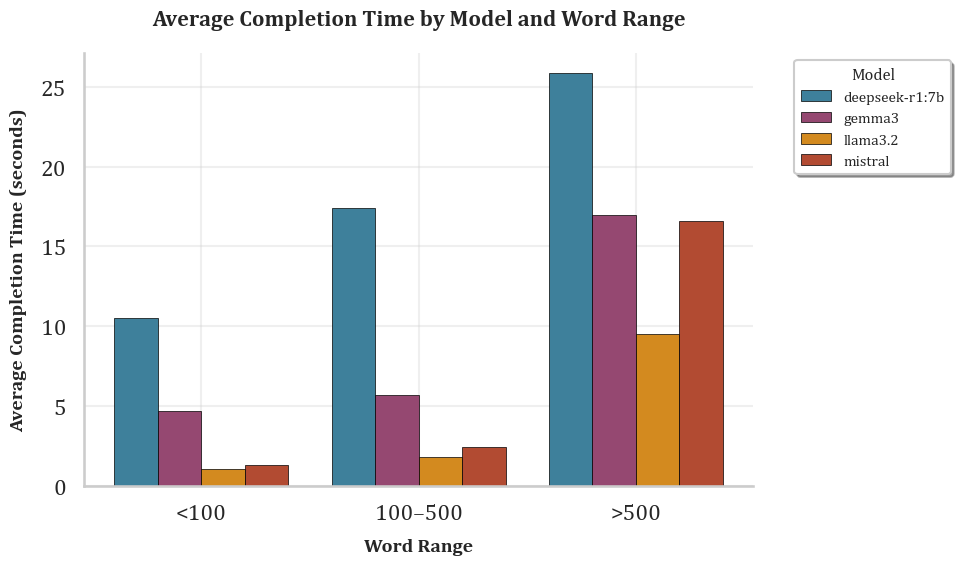

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Cambria font and academic style
plt.rcParams['font.family'] = 'Cambria'
plt.rcParams['font.size'] = 12
sns.set(style="whitegrid", context="talk", font="Cambria")

# Academic color palette (professional and accessible)
nature_palette = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F"]

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=summary, x="word_range", y="mean", hue="model", 
                 palette=academic_palette, ci=None, edgecolor="black", linewidth=0.5)

# Add error bars
plt.errorbar(
    x=range(len(summary["word_range"].unique())),
    y=summary.groupby("word_range")["mean"].mean(),
    yerr=summary.groupby("word_range")["std"].mean(),
    fmt="none", c="black", capsize=5, capthick=1, elinewidth=1
)

# Academic styling
plt.title("Average Completion Time by Model and Word Range", 
          fontsize=16, weight="bold", pad=20)
plt.xlabel("Word Range", fontsize=14, weight="bold", labelpad=10)
plt.ylabel("Average Completion Time (seconds)", fontsize=14, weight="bold", labelpad=10)

# Professional legend
plt.legend(title="Model", title_fontsize=12, fontsize=11, 
           bbox_to_anchor=(1.05, 1), loc="upper left", 
           frameon=True, fancybox=True, shadow=True)

# Grid and spines for academic look
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\mkarim1\AppData\Local\Temp\ipykernel_2472\3689614971.py:6: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(data=summary, x="word_range", y="mean", hue="model",


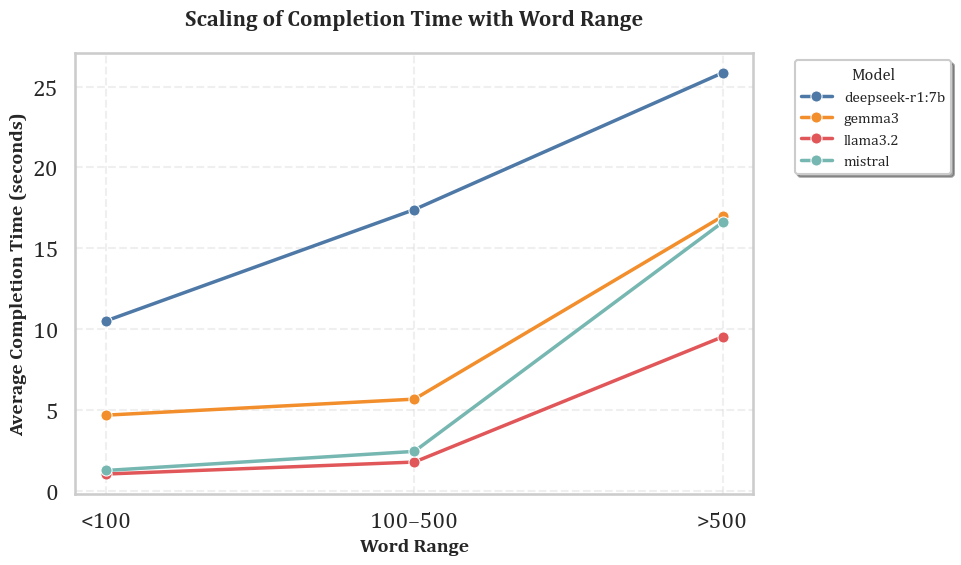

In [14]:
plt.figure(figsize=(10, 6))

# Nature journal color palette
nature_palette = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F"]

sns.lineplot(data=summary, x="word_range", y="mean", hue="model", 
             marker="o", markersize=8, linewidth=2.5, palette=nature_palette)

plt.title("Scaling of Completion Time with Word Range", 
          fontsize=16, weight="bold", pad=20)
plt.xlabel("Word Range", fontsize=14, weight="bold")
plt.ylabel("Average Completion Time (seconds)", fontsize=14, weight="bold")

plt.legend(title="Model", title_fontsize=12, fontsize=11,
           bbox_to_anchor=(1.05, 1), loc="upper left",
           frameon=True, fancybox=True, shadow=True)

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

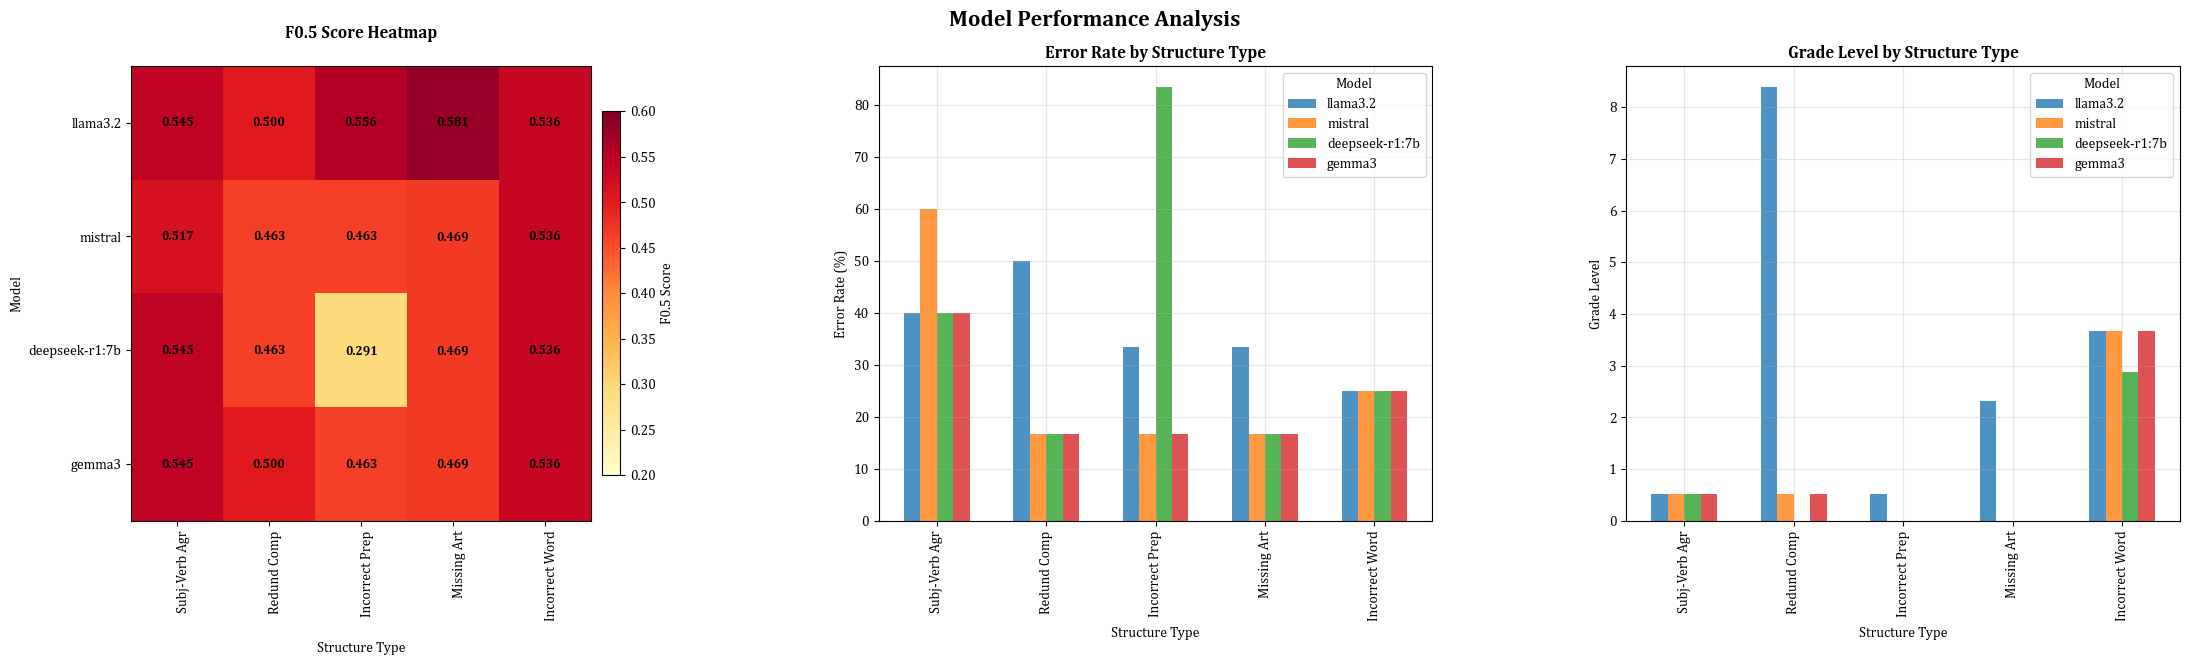

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set Cambria font for all text
plt.rcParams['font.family'] = 'Cambria'
plt.rcParams['font.size'] = 10

# Create DataFrame from the provided data
data = {
    'f05': [0.545, 0.517, 0.545, 0.545, 0.5, 0.463, 0.463, 0.5, 0.556, 0.463, 0.291, 0.463, 0.581, 0.469, 0.469, 0.469, 0.536, 0.536, 0.536, 0.536],
    'err': [40.00, 60.00, 40.00, 40.00, 50.00, 16.67, 16.67, 16.67, 33.33, 16.67, 83.33, 16.67, 33.33, 16.67, 16.67, 16.67, 25.00, 25.00, 25.00, 25.00],
    'grade_level': [0.52, 0.52, 0.52, 0.52, 8.38, 0.52, 0, 0.52, 0.52, 0, 0, 0, 2.31, 0, 0, 0, 3.67, 3.67, 2.88, 3.67],
    'model': ['llama3.2', 'mistral', 'deepseek-r1:7b', 'gemma3', 
              'llama3.2', 'mistral', 'deepseek-r1:7b', 'gemma3',
              'llama3.2', 'mistral', 'deepseek-r1:7b', 'gemma3',
              'llama3.2', 'mistral', 'deepseek-r1:7b', 'gemma3',
              'llama3.2', 'mistral', 'deepseek-r1:7b', 'gemma3'],
    'Structure Type': ['Subject Verb Agreement', 'Subject Verb Agreement', 'Subject Verb Agreement', 'Subject Verb Agreement',
                      'Redundant Comparison', 'Redundant Comparison', 'Redundant Comparison', 'Redundant Comparison',
                      'Incorrect Preposition Usage', 'Incorrect Preposition Usage', 'Incorrect Preposition Usage', 'Incorrect Preposition Usage',
                      'Missing Article', 'Missing Article', 'Missing Article', 'Missing Article',
                      'Incorrect Word Form', 'Incorrect Word Form', 'Incorrect Word Form', 'Incorrect Word Form']
}

df = pd.DataFrame(data)

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Model Performance Analysis', fontsize=16, fontweight='bold', fontfamily='Cambria')

# --- PLOT 1: Heatmap for F0.5 scores ---
structure_types = df['Structure Type'].unique()
models = df['model'].unique()

abbreviated_labels = [
    'Subj-Verb Agr',
    'Redund Comp',
    'Incorrect Prep',
    'Missing Art',
    'Incorrect Word'
]

# Create F0.5 score matrix
f05_matrix = np.zeros((len(models), len(structure_types)))
for i, model in enumerate(models):
    for j, st in enumerate(structure_types):
        f05_matrix[i, j] = df[(df['model'] == model) & (df['Structure Type'] == st)]['f05'].values[0]

im = ax1.imshow(f05_matrix, cmap='YlOrRd', aspect='auto', vmin=0.2, vmax=0.6)
ax1.set_xticks(np.arange(len(structure_types)))
ax1.set_yticks(np.arange(len(models)))
ax1.set_xticklabels(abbreviated_labels, rotation=90, ha='right', rotation_mode='anchor')
ax1.set_yticklabels(models)

# Add value annotations
for i in range(len(models)):
    for j in range(len(structure_types)):
        ax1.text(j, i, f'{f05_matrix[i, j]:.3f}', 
                ha='center', va='center', fontweight='bold', fontsize=9)

ax1.set_title('F0.5 Score Heatmap', fontweight='bold', pad=20)
ax1.set_xlabel('Structure Type', labelpad=15)
ax1.set_ylabel('Model')

cbar = plt.colorbar(im, ax=ax1, shrink=0.8, pad=0.02)
cbar.set_label('F0.5 Score')

# --- PLOT 2: Error Rate grouped by Structure Type ---
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
positions = np.arange(len(structure_types))
width = 0.15

for i, model in enumerate(models):
    subset = df[df['model'] == model]
    means = [subset[subset['Structure Type'] == st]['err'].values[0] for st in structure_types]
    ax2.bar(positions + i*width, means, width, label=model, color=colors[i], alpha=0.8)

ax2.set_xticks(positions + width*(len(models)-1)/2)
ax2.set_xticklabels(abbreviated_labels, rotation=90)
ax2.set_title('Error Rate by Structure Type', fontweight='bold')
ax2.set_ylabel('Error Rate (%)')
ax2.set_xlabel('Structure Type')
ax2.legend(title='Model')
ax2.grid(True, alpha=0.3)

# --- PLOT 3: Grade Level grouped by Structure Type ---
for i, model in enumerate(models):
    subset = df[df['model'] == model]
    means = [subset[subset['Structure Type'] == st]['grade_level'].values[0] for st in structure_types]
    ax3.bar(positions + i*width, means, width, label=model, color=colors[i], alpha=0.8)

ax3.set_xticks(positions + width*(len(models)-1)/2)
ax3.set_xticklabels(abbreviated_labels, rotation=90)
ax3.set_title('Grade Level by Structure Type', fontweight='bold')
ax3.set_ylabel('Grade Level')
ax3.set_xlabel('Structure Type')
ax3.legend(title='Model')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.90, bottom=0.25, wspace=0.35)
plt.show()


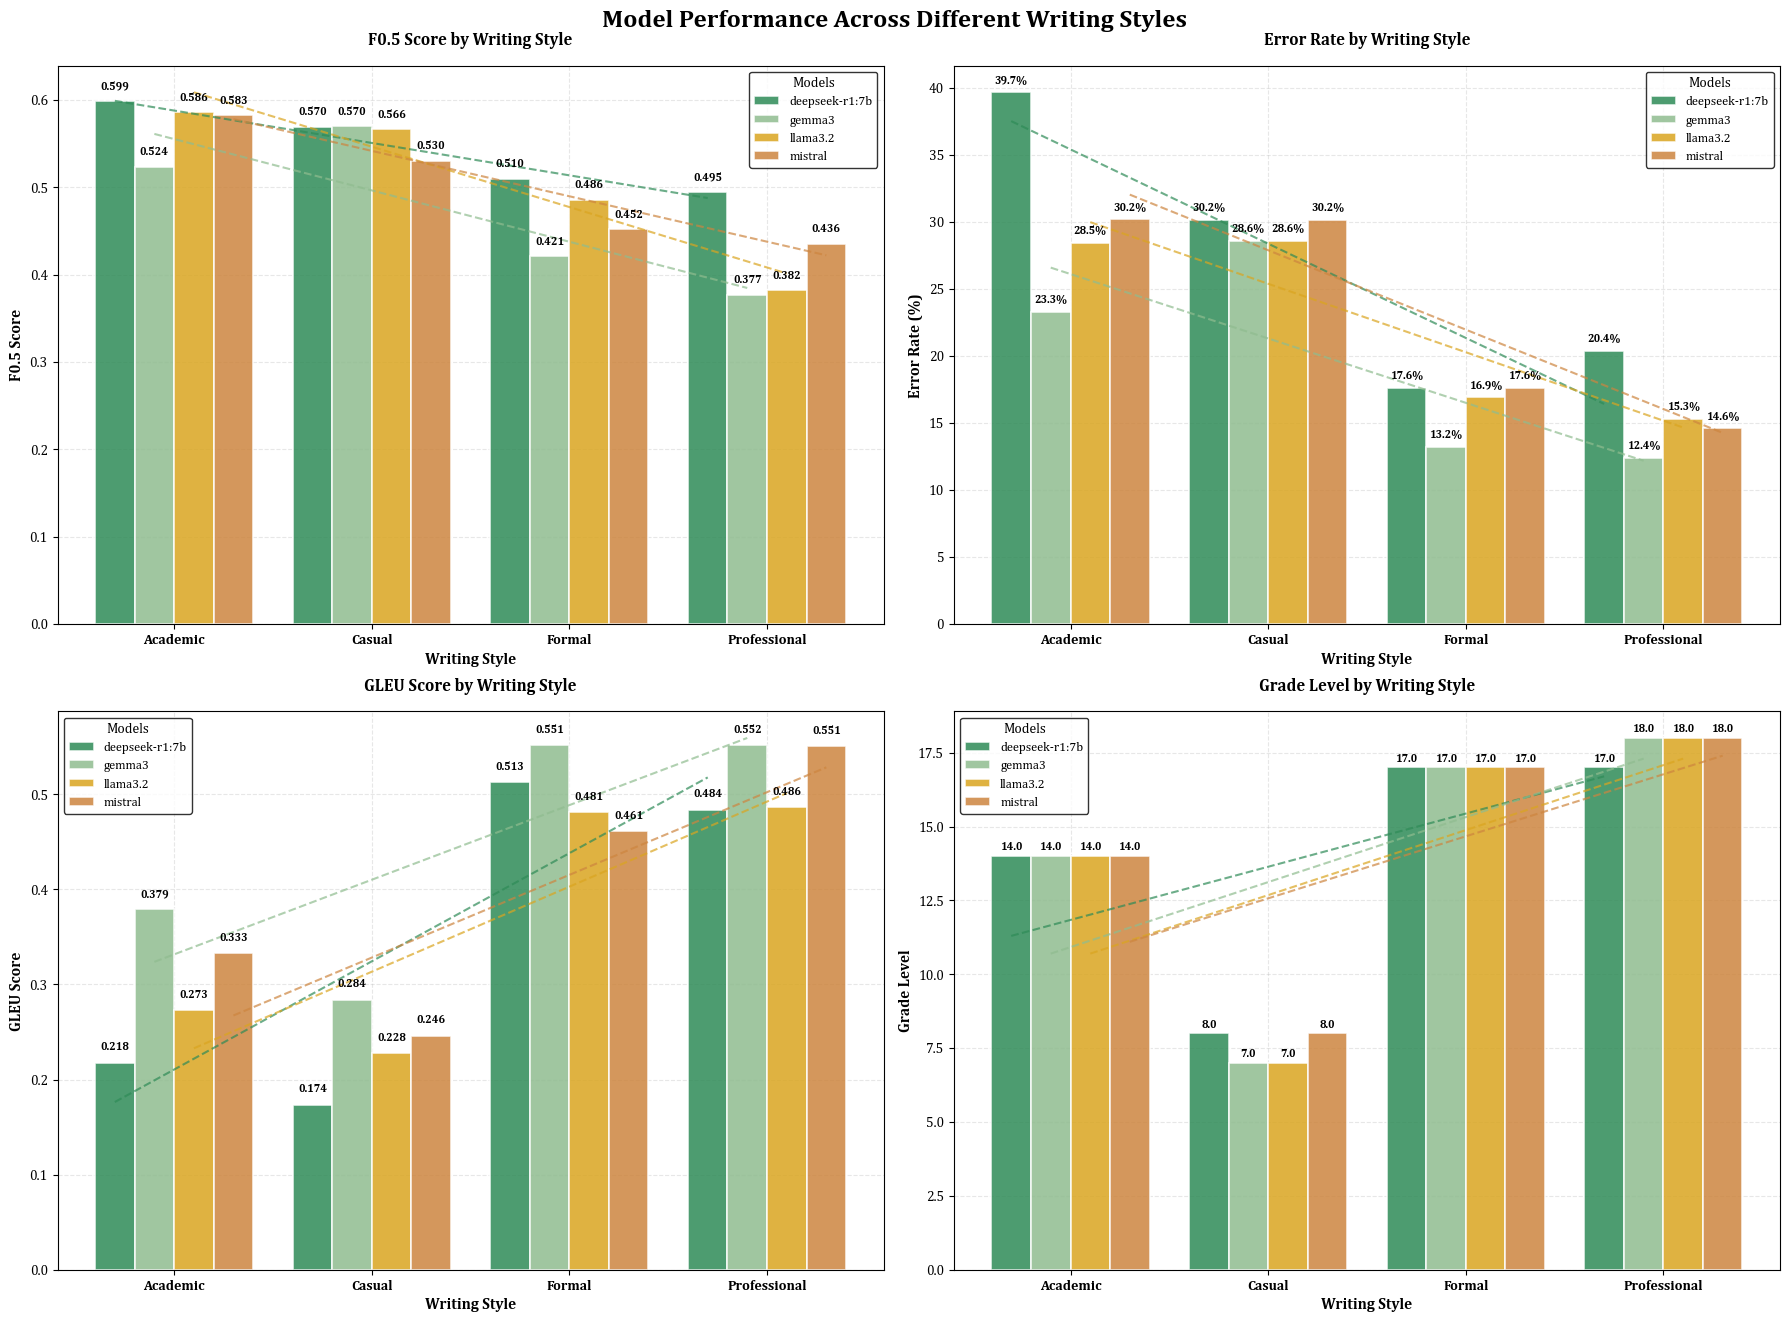

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Set Cambria font for all text
plt.rcParams['font.family'] = 'Cambria'
plt.rcParams['font.size'] = 10

# Load the data
df = pd.read_csv('synthetic_k_anon_data.csv')

# Calculate mean values for each model and style combination
summary_df = df.groupby(['model', 'style']).agg({
    'f05': 'mean',
    'err': 'mean', 
    'gleu': 'mean',
    'grade_level': 'mean'
}).reset_index()

# Create a 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Model Performance Across Different Writing Styles', fontsize=18, fontweight='bold', fontfamily='Cambria', y=0.98)

# Nature-inspired color palette (forest colors)
nature_colors = ['#2E8B57', '#8FBC8F', '#DAA520', '#CD853F']  # SeaGreen, DarkSeaGreen, GoldenRod, Peru
models = df['model'].unique()
model_colors = dict(zip(models, nature_colors))

# Plot 1: F0.5 Scores by Style and Model
styles = summary_df['style'].unique()
x_pos = np.arange(len(styles))
bar_width = 0.2

for i, model in enumerate(models):
    model_data = summary_df[summary_df['model'] == model]
    values = [model_data[model_data['style'] == style]['f05'].values[0] for style in styles]
    bars = axes[0,0].bar(x_pos + i * bar_width, values, bar_width, label=model, 
                        color=model_colors[model], alpha=0.85, edgecolor='white', linewidth=1.2)
    
    for j, bar in enumerate(bars):
        height = bar.get_height()
        axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                      f'{height:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold',
                      fontfamily='Cambria')

axes[0,0].set_title('F0.5 Score by Writing Style', fontweight='bold', fontfamily='Cambria', pad=15, fontsize=12)
axes[0,0].set_xlabel('Writing Style', fontfamily='Cambria', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('F0.5 Score', fontfamily='Cambria', fontsize=11, fontweight='bold')
axes[0,0].set_xticks(x_pos + bar_width * 1.5)
axes[0,0].set_xticklabels(styles, fontfamily='Cambria', fontweight='bold')
axes[0,0].grid(True, alpha=0.3, linestyle='--')
axes[0,0].set_axisbelow(True)

# Add trendline for F0.5 (excluded from legend)
for i, model in enumerate(models):
    model_data = summary_df[summary_df['model'] == model]
    values = [model_data[model_data['style'] == style]['f05'].values[0] for style in styles]
    x_trend = x_pos + i * bar_width
    z = np.polyfit(x_trend, values, 1)
    p = np.poly1d(z)
    axes[0,0].plot(x_trend, p(x_trend), color=model_colors[model], linestyle='--', 
                  alpha=0.7, linewidth=1.5, label='_nolegend_')

axes[0,0].legend(title='Models', loc='upper right', fontsize=9, title_fontsize=10,
                 frameon=True, facecolor='white', edgecolor='black')

# Plot 2: Error Rate by Style and Model
for i, model in enumerate(models):
    model_data = summary_df[summary_df['model'] == model]
    values = [model_data[model_data['style'] == style]['err'].values[0] for style in styles]
    bars = axes[0,1].bar(x_pos + i * bar_width, values, bar_width, label=model, 
                        color=model_colors[model], alpha=0.85, edgecolor='white', linewidth=1.2)
    
    for j, bar in enumerate(bars):
        height = bar.get_height()
        axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                      f'{height:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold',
                      fontfamily='Cambria')

axes[0,1].set_title('Error Rate by Writing Style', fontweight='bold', fontfamily='Cambria', pad=15, fontsize=12)
axes[0,1].set_xlabel('Writing Style', fontfamily='Cambria', fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('Error Rate (%)', fontfamily='Cambria', fontsize=11, fontweight='bold')
axes[0,1].set_xticks(x_pos + bar_width * 1.5)
axes[0,1].set_xticklabels(styles, fontfamily='Cambria', fontweight='bold')
axes[0,1].grid(True, alpha=0.3, linestyle='--')
axes[0,1].set_axisbelow(True)

# Add trendline for Error Rate (excluded from legend)
for i, model in enumerate(models):
    model_data = summary_df[summary_df['model'] == model]
    values = [model_data[model_data['style'] == style]['err'].values[0] for style in styles]
    x_trend = x_pos + i * bar_width
    z = np.polyfit(x_trend, values, 1)
    p = np.poly1d(z)
    axes[0,1].plot(x_trend, p(x_trend), color=model_colors[model], linestyle='--',
                  alpha=0.7, linewidth=1.5, label='_nolegend_')

axes[0,1].legend(title='Models', loc='upper right', fontsize=9, title_fontsize=10,
                 frameon=True, facecolor='white', edgecolor='black')

# Plot 3: GLEU Score by Style and Model
for i, model in enumerate(models):
    model_data = summary_df[summary_df['model'] == model]
    values = [model_data[model_data['style'] == style]['gleu'].values[0] for style in styles]
    bars = axes[1,0].bar(x_pos + i * bar_width, values, bar_width, label=model, 
                        color=model_colors[model], alpha=0.85, edgecolor='white', linewidth=1.2)
    
    for j, bar in enumerate(bars):
        height = bar.get_height()
        axes[1,0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                      f'{height:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold',
                      fontfamily='Cambria')

axes[1,0].set_title('GLEU Score by Writing Style', fontweight='bold', fontfamily='Cambria', pad=15, fontsize=12)
axes[1,0].set_xlabel('Writing Style', fontfamily='Cambria', fontsize=11, fontweight='bold')
axes[1,0].set_ylabel('GLEU Score', fontfamily='Cambria', fontsize=11, fontweight='bold')
axes[1,0].set_xticks(x_pos + bar_width * 1.5)
axes[1,0].set_xticklabels(styles, fontfamily='Cambria', fontweight='bold')
axes[1,0].grid(True, alpha=0.3, linestyle='--')
axes[1,0].set_axisbelow(True)

# Add trendline for GLEU Score (excluded from legend)
for i, model in enumerate(models):
    model_data = summary_df[summary_df['model'] == model]
    values = [model_data[model_data['style'] == style]['gleu'].values[0] for style in styles]
    x_trend = x_pos + i * bar_width
    z = np.polyfit(x_trend, values, 1)
    p = np.poly1d(z)
    axes[1,0].plot(x_trend, p(x_trend), color=model_colors[model], linestyle='--',
                  alpha=0.7, linewidth=1.5, label='_nolegend_')

axes[1,0].legend(title='Models', loc='upper left', fontsize=9, title_fontsize=10,
                 frameon=True, facecolor='white', edgecolor='black')

# Plot 4: Grade Level by Style and Model
for i, model in enumerate(models):
    model_data = summary_df[summary_df['model'] == model]
    values = [model_data[model_data['style'] == style]['grade_level'].values[0] for style in styles]
    bars = axes[1,1].bar(x_pos + i * bar_width, values, bar_width, label=model,
                        color=model_colors[model], alpha=0.85, edgecolor='white', linewidth=1.2)
    
    for j, bar in enumerate(bars):
        height = bar.get_height()
        axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                      f'{height:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold',
                      fontfamily='Cambria')

axes[1,1].set_title('Grade Level by Writing Style', fontweight='bold', fontfamily='Cambria', pad=15, fontsize=12)
axes[1,1].set_xlabel('Writing Style', fontfamily='Cambria', fontsize=11, fontweight='bold')
axes[1,1].set_ylabel('Grade Level', fontfamily='Cambria', fontsize=11, fontweight='bold')
axes[1,1].set_xticks(x_pos + bar_width * 1.5)
axes[1,1].set_xticklabels(styles, fontfamily='Cambria', fontweight='bold')
axes[1,1].grid(True, alpha=0.3, linestyle='--')
axes[1,1].set_axisbelow(True)

# Add trendline for Grade Level (excluded from legend)
for i, model in enumerate(models):
    model_data = summary_df[summary_df['model'] == model]
    values = [model_data[model_data['style'] == style]['grade_level'].values[0] for style in styles]
    x_trend = x_pos + i * bar_width
    z = np.polyfit(x_trend, values, 1)
    p = np.poly1d(z)
    axes[1,1].plot(x_trend, p(x_trend), color=model_colors[model], linestyle='--',
                  alpha=0.7, linewidth=1.5, label='_nolegend_')

axes[1,1].legend(title='Models', loc='upper left', fontsize=9, title_fontsize=10,
                 frameon=True, facecolor='white', edgecolor='black')

plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.08)
plt.show()
